In [15]:
from utils import write_to_file,get_distinct_values,get_count
import pandas as pd
import numpy as np

# Data Cleaning

## Rename columns and Combine Datasets

In [3]:
# stop number of columns at the end that don't have the year in the column name
def remove_year_from_column_name(dataset, stop):
    list_columns = list(dataset.columns)

    for i in range(0,len(list_columns)-stop):
        list_columns[i] = list_columns[i][:-5]

    dataset.columns = list_columns
    
def rename_datasets():
    # Save each .sav as a data frame
    df_20 = pd.read_spss("Datasets/NPORS-2020/dataset.sav")
    df_21 = pd.read_spss("Datasets/NPORS-2021/dataset.sav")
    df_22 = pd.read_spss("Datasets/NPORS-2022/dataset.sav")
    df_23 = pd.read_spss("Datasets/NPORS-2023/dataset.sav")
    df_24 = pd.read_spss("Datasets/NPORS-2024/dataset.sav")
    df_25 = pd.read_spss("Datasets/NPORS-2025/dataset.sav")

    # convert .sav to .csv
    write_to_file(df_20,"Datasets/NPORS-2020/dataset_20.csv")
    write_to_file(df_21,"Datasets/NPORS-2021/dataset_21.csv")
    write_to_file(df_22,"Datasets/NPORS-2022/dataset_22.csv")
    write_to_file(df_23,"Datasets/NPORS-2023/dataset_23.csv")
    write_to_file(df_24,"Datasets/NPORS-2024/dataset_24.csv")
    write_to_file(df_25,"Datasets/NPORS-2025/dataset_25.csv")
    
    # Remove the year from column name to keep naming consistant
    remove_year_from_column_name(df_20, 5)
    remove_year_from_column_name(df_21, 2)

    # ensure columns recording the same data have the same name
    # so there aren't duplicate columns when appending datasets
    df_20 = df_20.rename(columns={
        'DEVICE1a':'DEVICE',
        'EDUC_ACS':'EDUCATION',
        'HLTHRATE':'HEALTH',
        'NATIVITY':'BIRTHPLACE',
        'NUMADULTS':'HH_ADULTS',
        'REG':'REG_VOTE',
        'REGION_NAME':'REGION',
        'SEXASK':'GENDER', 
        'SMART2':'SMART',
        'VET1':'VET',
        'VOL12_CPS':'VOL'
    })

    df_21 = df_21.rename(columns={
        'ADULTSINHH':'HH_ADULTS',
        'BOOKS1':'BOOKS',
        'DEVICE1a':'DEVICE',
        'GOVSIZE1':'GOVSIZE',
        'LANG':'LANGUAGE',
        'NATIVITY':'BIRTHPLACE',
        'REG':'REG_VOTE',
        'SMART2':'SMART',
        'VET1':'VET',
        'VOL12_CPS':'VOL'
    })

    df_22 = df_22.rename(columns={
        'ADULTSINHH':'HH_ADULTS',
        'BBHOME':'HOMEINTSERV',
        'BOOKS1':'BOOKS',
        'COMTYPE2':'COMTYPE',
        'CREGION':'REGION',
        'DEVICE1a':'DEVICE',
        'DISAMOD':'DISA',
        'GOVSIZE1':'GOVSIZE',
        'LANG_PREF':'LANGUAGE',
        'NATIVITY':'BIRTHPLACE',
        'PSTRATA':'STRATUM',
        'REG':'REG_VOTE',
        'SMART2':'SMART',
        'VET1':'VET',
        'VOL12_CPS':'VOL'
    })

    df_23 = df_23.rename(columns={
        'ADULTS':'HH_ADULTS',
        'ATTENDONLINE2':'ATTEND_ONLINE',
        'BASEWT':'BASEWEIGHT', 
        'BBHOME':'HOMEINTSERV',
        'BOOKS1':'BOOKS',
        'COMTYPE2':'COMTYPE',
        'CREGION':'REGION',
        'DEVICE1a':'DEVICE',
        'INC_SDT1':'INCOME',
        'LANGUAGE_PREF':'LANGUAGE',
        'MODE_2WAY':'MODE',
        'RELIGCAT1':'RELIG_CAT',
        'SMART2':'SMART',
        'VET1':'VET',
        'VOL12_CPS':'VOL'
    })

    df_24 = df_24.rename(columns={
        'ADULTS':'HH_ADULTS',
        'ATTENDONLINE2':'ATTEND_ONLINE',
        'ATTENDPER':'ATTEND',
        'BASEWT':'BASEWEIGHT', 
        'BBHOME':'HOMEINTSERV',
        'BIDENT1_GEOSTRATA':'STRATUM',
        'COMTYPE2':'COMTYPE',
        'CREGION':'REGION',
        'DEVICE1A':'DEVICE',
        'INC_SDT1': 'INCOME',
        'RELIGCAT1':'RELIG_CAT',
        'SMART2':'SMART',
        'SMUSEa' : 'SMUSE_a','SMUSEd' : 'SMUSE_d','SMUSEg' : 'SMUSE_g','SMUSEj' : 'SMUSE_j',
        'SMUSEb' : 'SMUSE_b','SMUSEe' : 'SMUSE_e','SMUSEh' : 'SMUSE_h','SMUSEk' : 'SMUSE_k',
        'SMUSEc' : 'SMUSE_c','SMUSEf' : 'SMUSE_f','SMUSEi' : 'SMUSE_i',
        'SURVEYENDDATE':'INTERVIEW_END',
        'SURVEYSTARTDATE':'INTERVIEW_START',
        'VET1':'VET',
        'VOL12_CPS':'VOL'
    })

    df_25 = df_25.rename(columns={
        'ADULTS':'HH_ADULTS',
        'ATTENDONLINE2':'ATTEND_ONLINE',
        'ATTENDPER':'ATTEND',
        'BASEWT':'BASEWEIGHT', 
        'BBHOME':'HOMEINTSERV',
        'COMTYPE2':'COMTYPE',
        'CREGION':'REGION',
        'DEVICE1A':'DEVICE',
        'INC_SDT1': 'INCOME',
        'RELIGCAT1':'RELIG_CAT',
        'SMART2':'SMART',
        'SMUSE_FB':'SMUSE_a',
        'SMUSE_YT':'SMUSE_b',
        'SMUSE_X':'SMUSE_c',
        'SMUSE_IG':'SMUSE_d',
        'SMUSE_SC':'SMUSE_e',
        'SMUSE_WA':'SMUSE_f',
        'SMUSE_TT':'SMUSE_i',
        'SMUSE_RD':'SMUSE_k',
        'SMUSE_BSK':'SMUSE_l',
        'SMUSE_TH':'SMUSE_m',
        'SMUSE_TS':'SMUSE_n',
        'VET1':'VET',
        'VOL12_CPS':'VOL',
        'VOTEGEN_POST':'VOTEGEN_POST24'
    })
    
    return df_20,df_21,df_22,df_23,df_24,df_25

In [4]:
def combine():
    # add year columns to all datasets
    df_20['YEAR'] = 2020
    df_21['YEAR'] = 2021
    df_22['YEAR'] = 2022
    df_23['YEAR'] = 2023
    df_24['YEAR'] = 2024
    df_25['YEAR'] = 2025

    social_medias = ['SMUSE_a','SMUSE_b','SMUSE_c','SMUSE_d','SMUSE_e', 'SMUSE_f','SMUSE_g',
          'SMUSE_h','SMUSE_i','SMUSE_j','SMUSE_k','SMUSE_l','SMUSE_m','SMUSE_n']
    
    dataframes = [df_20,df_21,df_22,df_23,df_24,df_25]

    # for each dataset and for each social media, we want to replace null 
    # values with "Refused" if the social media was asked
    for i in range(len(dataframes)) :
        for social_media in social_medias:
            df = dataframes[i]
            # check if social media column exists
            if social_media in df.columns:
                df[social_media] = df[social_media].astype(str)
                df[social_media] = df[social_media].replace({"nan":"Refused"})

    # Combine (append) all datasets together
    df_combined = pd.concat([df_20, df_21, df_22, df_23, df_24, df_25])

    return df_combined

In [5]:
df_20,df_21,df_22,df_23,df_24,df_25 = rename_datasets()
df_combined = combine()
df_combined.shape

(28469, 110)

## Replace Values

In [6]:
def get_vals(df_combined):
    df_vals = pd.DataFrame({'var':[],'vals':[]})
    for column in list(df_combined.columns):
        vals = get_distinct_values(df_combined,column)
        df = pd.DataFrame({'var':column,'vals':vals})
        df_vals = pd.concat([df_vals,df])

    df_vals = df_vals[~df_vals['var'].isin([
        'RESPID','WEIGHT','BASEWEIGHT','STRATUM','INTERVIEW_START','INTERVIEW_END','DATERECEIVED',
        'BOOKS','AGE'
    ])]
    df_vals = df_vals.sort_values(by='var')
    write_to_file(df_vals)
    print(len(df_vals))

In [7]:
def replace_values(df_combined):
    df_combined = df_combined.replace({
        r'(?i).*Refused.*':'Refused',
        'Yes, use this':'Yes',
        'No, don’t use this':'No',
        'No, don\'t use this':'No'
    },regex=True)

    df_combined['BIRTHPLACE'] = df_combined['BIRTHPLACE'].replace({
        r'(?i).*Puerto Rico.*':'Puerto Rico',
        r'(?i).*Another Country.*':'Another Country',
        r'(?i).*Other.*':'Other U.S Territory',
        r'(?i).*50 States.*':'U.S.',
    },regex=True)

    df_combined['DEVICE'] = df_combined['DEVICE'].replace({
        r'(?i).*Yes.*':'Yes',
        r'(?i).*No.*':'No'
    },regex=True)

    df_combined['ECON1MOD'] = df_combined['ECON1MOD'].replace({
        'Only fair':'Only Fair',
    })

    df_combined['EDUCATION'] = df_combined['EDUCATION'].replace({
        r'.*11.*':'Some High School',
        r'.*12.*':'Some High School',
        r'.*high school.*':'High School',
        r'.*GED.*':'High School',
        r'.*college.*':'Some College',
        r'.*Associate.*':'Associate\'s Degree',
        r'.*Bachelor.*':'Bachelor\'s Degree',
        r'.*Master.*':'Master\'s Degree or Higher',
        r'.*MD.*':'Master\'s Degree or Higher',
        r'.*Doctorate.*':'Master\'s Degree or Higher',
        'Kindergarten':'Other'
    },regex=True)


    df_combined['GENDER'] = df_combined['GENDER'].replace({
        "A man":"Male",
        "A woman":"Female",
        "In some other way":"Other"
    })

    df_combined["HH_ADULTS"] = (
        df_combined["HH_ADULTS"]
            .astype(str)
            .str.strip()
            .replace({
                '1.0':'1',
                '2.0':'2',
                '3.0':'3',
                '4.0':'4',
                '5.0':'5+',
                '6.0':'5+',
                '7.0':'5+',
                '8.0':'5+',
                '5 or more':'5+'
            })
    )

    df_combined['HOMEINTSERV'] = df_combined['HOMEINTSERV'].replace({
        r'(?i).*high-speed.*':'High-Speed Internet Service',
        r'(?i).*Dial.*':'Dial-up Service',
        r'(?i).*Satellite.*':'Satellite Service',
        r'(?i).*Other.*':'Other'
    },regex=True)

    df_combined["INCOME"] = df_combined["INCOME"].replace({
        r' to less than ':'-',
        r' or more':'+',
        r'Less than':'<',
        r',000':'K',
    },regex=True)

    df_combined['INTFREQ'] = df_combined['INTFREQ'].replace({
        r'(?i).*not use.*':"Don't Use"
    },regex=True)

    df_combined['LANGUAGE'] = df_combined['LANGUAGE'].replace({
        "Español":"Spanish"
    })

    df_combined['LANG_PREF'] = df_combined['LANG_PREF'].replace({
        "Español":"Spanish"
    })

    df_combined['MARITAL'] = df_combined['MARITAL'].replace({
        "Separated":"Divorced",
        "Never been married":"Never married",
    })

    df_combined['MODE'] = df_combined['MODE'].replace({
        r'(?i).*mail.*':'Mail'
    },regex=True)

    df_combined['PARTYSUM'] = df_combined['PARTYSUM'].replace({
        r'(?i).*Dem.*':'Lean Democrat',
        r'(?i).*Rep.*':'Lean Republican'
    },regex=True)

    df_combined["RACECMB"] = df_combined["RACECMB"].replace({
        r'(?i).*Asian.*':'Asian',
        r'(?i).*Black.*':'Black',
        r'(?i).*other.*':'Other',
        'Mixed race':'Mixed Race'
    },regex=True)

    df_combined[['RACEMOD_1','RACEMOD_2','RACEMOD_3','RACEMOD_4','RACEMOD_5','RACEMOD_6','RACEMOD_99']] = (
        df_combined[['RACEMOD_1','RACEMOD_2','RACEMOD_3','RACEMOD_4','RACEMOD_5','RACEMOD_6','RACEMOD_99']].replace({
            0.0:'No',
            'Not selected':'No',
            'Selected':'Yes',
            'White':'Yes',
            'Black or African American':'Yes',
            r'(?i).*Asian.*':'Yes',
            'American Indian or Alaska Native':'Yes',
            'Native Hawaiian or other Pacific Islander':'Yes',
            'Some other race or origin':'Yes'
        },regex=True)
    )

    df_combined["RELIG"] = df_combined["RELIG"].replace({
        r'(?i).*Mormon.*':'Mormon',
        r'(?i).*Orthodox.*':'Orthodox',
        r'(?i).*Protestant.*':'Protestant',
        r'(?i).*Something else.*':'Other'
    },regex=True)

    # replace values so we can convert to int
    df_combined["AGE"] = df_combined["AGE"].replace({
        # "n/a":"-1",
        "98+":"98",
        "":"-1",
        'Refused':"-1"
    })

    df_combined["BOOKS"] = df_combined["BOOKS"].replace({
        'Refused':"-1",
        "95 or more":"95",
        "100 or more":"100",
        "100+":"100"
    })

    # change column type
    df_combined[['AGE','BOOKS']] = df_combined[['AGE','BOOKS']].fillna('-1')
    df_combined["AGE"] = df_combined["AGE"].astype(int)
    df_combined["BOOKS"] = df_combined["BOOKS"].astype(int)
    return df_combined

In [8]:
df_combined = replace_values(df_combined)
get_vals(df_combined)

508


In [9]:
write_to_file(df_combined[0:18])

## Rename Combined Dataset Columns

In [10]:
def rename_columns(df_combined):
    # # Keep relevent columns only
    # df_combined = df_combined[[
    #     'RESPID','YEAR','AGE','AGEGRP','GENDER','RACECMB', # basic demographics
    #     'INCOME','EDUCATION', 'REGION','RELIG', 'PARTY', # other useful demographics 
    #     'RELIMP','MARITAL', # other features
    #     'SMUSE_a', 'SMUSE_b', 'SMUSE_c', 'SMUSE_d', 'SMUSE_e', 'SMUSE_f', # social media use
    #     'SMUSE_g','SMUSE_h','SMUSE_i','SMUSE_j','SMUSE_k','SMUSE_l','SMUSE_m','SMUSE_n',
    #     'ECON1MOD', 'ECON1BMOD', # we want to study how this changes over time
    #     'BASEWEIGHT', 'WEIGHT' # weights 
    # ]]
    # rename columns
    df_combined = df_combined.rename(columns={
        'SMUSE_a':'FACEBOOK',
        'SMUSE_b':'YOUTUBE',
        'SMUSE_c':'TWITTER',
        'SMUSE_d':'INSTAGRAM',
        'SMUSE_e':'SNAPCHAT',
        'SMUSE_f':'WHATSAPP',
        'SMUSE_g':'LINKEDIN',
        'SMUSE_h':'PINTEREST',
        'SMUSE_i':'TIKTOK',
        'SMUSE_j':'BEREAL',
        'SMUSE_k':'REDDIT',
        'SMUSE_l':'BLUESKY',
        'SMUSE_m':'THREADS',
        'SMUSE_n':'TRUTHSOCIAL',
        'RACECMB':'RACE',
        'ECON1MOD':'Econ_Rating',
        'ECON1BMOD':'Econ_Outlook',  
        'RELIG':'Religion',
        'RELIMP':'Faith_Importance',
        'PRAY':'Pray_Freq'                                                                                                                    
    })

    df_combined.columns = df_combined.columns.str.title()
    return df_combined

In [11]:
df_combined = rename_columns(df_combined)
df_combined.shape

(28469, 110)

## Create Calculated Columns

In [12]:
def create_calculated_columns(df_combined):
    # conditions for each group
    conditions = [
        df_combined['Income'].isin(['$10K-$20K','$20K-$30K','$30K-$40K','< $10K','< $30K']),
        df_combined['Income'].isin(['$40K-$50K','$50K-$60K','$60K-$70K','$50K-$70K']),
        df_combined['Income'].isin(['$70K-$100K','$70K-$80K','$70K-$90K','$75K-$100K','$80K-$90K','$90K-$100K']),
        df_combined['Income'].isin(['$100K+','$100K-$125K','$100K-$150K','$125K-$150K','$150K+']),
        df_combined['Income'] == 'Refused'
    ]
    # corresponding groups for each condition
    group = ['< $40K','$40-70K','$70-100K','$100K+','Refused']

    # insert new column after INCOME
    df_combined.insert(
        df_combined.columns.get_loc('Income') + 1, # position we want to insert at
        'Income_Cat', # name of new column
        np.select(conditions, group, default='Refused') # set value according to conditions 
    )

    conditions = [
        (df_combined['Agegrp'] == '18-24') | ((18 <= df_combined['Age']) & (df_combined['Age'] <= 24)),
        (df_combined['Agegrp'].isin(['25-29','30-34','35-39'])) | ((25 <= df_combined['Age']) & (df_combined['Age'] <= 39)),
        (df_combined['Agegrp'].isin(['40-44','45-49','50-54','55-59'])) | ((40 <= df_combined['Age']) & (df_combined['Age'] <= 59)),
        (df_combined['Agegrp'].isin(['60-64','65-69','70-74','75-79'])) | ((60 <= df_combined['Age']) & (df_combined['Age'] <= 79)),
        (df_combined['Agegrp'] == '80+')| (80 <= df_combined['Age']),
        (df_combined['Agegrp'] == 'Refused') | (df_combined['Age'] == -1)
    ]
    group = ['18-24','25-39','40-59','60-79','80+','Refused']

    df_combined.insert(
        df_combined.columns.get_loc('Agegrp') + 1, # position we want to insert at
        'Age_Cat', # name of new column
        np.select(conditions, group, default='Refused') # set value according to conditions 
    )
    rating = df_combined['Econ_Rating']
    overlook = df_combined['Econ_Outlook']
    conditions = [
        (rating.isin(['Excellent','Good'])) & (overlook.isin(['Better','About the same'])),
        ((rating == 'Poor') & (overlook.isin(['Worse','About the same']))) | ((rating == 'Only Fair') & (overlook == 'Worse')),
        (rating == 'Only Fair') & (overlook == 'About the same'),
        ((rating.isin(['Excellent','Good'])) & (overlook == 'Worse')) | ((rating == 'Poor') & (overlook == 'Better'))
            
    ]
    sentiment = ['Positive', 'Negative', 'Neutral', 'Mix']

    # create a new column that labels each rating as negative or positive
    df_combined.insert(
        df_combined.columns.get_loc('Econ_Outlook') + 1, # position we want to insert at
        'Econ_Sentiment', # name of new column
        np.select(conditions, sentiment, default='Refused') # set value according to conditions 
    )
    return df_combined

In [13]:
df_combined = create_calculated_columns(df_combined)
write_to_file(df_combined, 'Datasets/combined_dataset.csv')
write_to_file(df_combined[0:10])

# Exploratory Data Analysis

In [112]:
df_combined.shape

(28469, 113)

In [15]:
with pd.option_context('display.max_columns', None):
    display(df_combined[0:5])

,Respid,Language,Interview_Start,Interview_End,Econ_Rating,Econ_Outlook,Econ_Sentiment,Typologyb,Covidwork_A,Covidwork_B,Comattach,Vet,Vol,Health,Disa,Robwrk,Respfut,Eminuse,Intmob,Intfreq,Homeintserv,Facebook,Youtube,Twitter,Instagram,Snapchat,Whatsapp,Linkedin,Pinterest,Books,Radio,Device,Smart,Religion,Born,Attend,Faith_Importance,Pray_Freq,Reg_Vote,Insurance,Gender,Marital,Party,Partyln,Hisp,Racemod_1,Racemod_2,Racemod_3,Racemod_4,Racemod_5,Racemod_6,Race,Age,Education,Hh_Adults,Birthplace,Income,Income_Cat,Region,Msa,Mode,Baseweight,Weight,Year,Datereceived,Stratum,Govsize,Soctrust,Colspeech,Tiktok,Nhisll,Voted2020,Votegen_Post,Metro,Device_Type,Comtype,Home4Nw2,Racemod_99,Racethnmod,Books1_Refused,Partysum,Educcat,Division,Lang_Pref,Crimesafe,Police_Fund,Moregunimpact,Gunstrict,Intfreq_Collapsed,Bereal,Reddit,Relig_Cat,Attend_Online,Registration,Racemod_Mixedoe,Racethn,Agecat,Age_Refused,Languageinitial,Bwave,Unity,Infraspend,Gamblerestr,Gpt1,Govprotct,Fin_Sit,Bluesky,Threads,Truthsocial,Agegrp,Age_Cat,Voted2024,Votegen_Post24
0,1.0,English,2020-06-03,2020-06-03 10:58:13,Good,About the same,Positive,Business corporations make too much profit,"No, has not happened","No, has not happened",Somewhat attached,"No, nobody in household",No,Very good,No,Probably happen,The federal government,Yes,Yes,Several times a day,High-Speed Internet Service,Yes,No,No,No,No,No,No,No,20,No,Yes,"Yes, smartphone",Agnostic,NaN,Never,Not at all important,Never,You are ABSOLUTELY CERTAIN that you are regist...,Covered by health insurance,Female,Married,Democrat,NaN,No,Yes,No,No,No,No,No,White,71,Bachelor's Degree,2,U.S.,$50K-$75K,Refused,Northeast,Metropolitan Statistical Area,Online,2.131108,0.749664,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60-79,NaN,NaN
1,2.0,English,2020-06-03,2020-06-03 13:59:15,Only Fair,Worse,Negative,Business corporations make too much profit,"Yes, has happened","Yes, has happened",Very attached,"No, nobody in household",Yes,Excellent,No,Probably happen,The federal government,Yes,Yes,Almost constantly,High-Speed Internet Service,Yes,Yes,Yes,Yes,Yes,No,No,No,2,No,Yes,"Yes, smartphone",Nothing in particular,NaN,Seldom,Not too important,Seldom,"You are PROBABLY registered, but there is a ch...",Not covered by health insurance,Female,Never married,Something else,The Democratic Party,No,Yes,Yes,No,No,No,No,Mixed Race,23,High School,2,U.S.,< $10K,< $40K,Northeast,Metropolitan Statistical Area,Online,2.131108,3.430205,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18-24,NaN,NaN
2,3.0,English,2020-06-03,2020-06-03 15:09:45,Poor,Worse,Negative,Business corporations make too much profit,"Yes, has happened","Yes, has happened",Not at all attached,"No, nobody in household",No,Good,No,Definitely happen,The federal government,Yes,Yes,Several times a day,High-Speed Internet Service,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,1,Yes,Yes,"Yes, smartphone",Protestant,"Yes, born-again or evangelical Christian",Seldom,Very important,Once a day,You are ABSOLUTELY CERTAIN that you are regist...,Not covered by health insurance,Male,Living with a partner,Democrat,NaN,No,Yes,Yes,No,No,No,No,Mixed Race,37,Bachelor's Degree,2,U.S.,$20K-$30K,< $40K,Northeast,Metropolitan Statistical Area,Online,1.970167,0.881487,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25-39,NaN,NaN
3,4.0,English,2020-06-03,2020-06-03 15:07:33,Only Fair,Worse,Negative,Business corporations make too much profit,"No, has not happened","No, has not happened",Not at all attached,"No, nobody in household",No,Good,No,Probably happen,Individuals themselves,Yes,Yes,Almost con

In [95]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28469 entries, 0 to 5021
Columns: 113 entries, Respid to Votegen_Post24
dtypes: category(37), float64(3), int64(3), object(70)
memory usage: 17.7+ MB


# Causal Inference

- Method: Propensity Score
- Treatment: year = 2022
- Control: year = 2021
- Outcome: Econ_Sentiment = 'Negative'
- Covariates: All other features that are shared by the datasets 

## Extracting Covariates

In [31]:
intersection = ( 
    set(df_21.columns) & 
    set(df_22.columns)  
)

exclude = ['RESPID','STRATUM','WEIGHT','BASEWEIGHT','INTERVIEW_START','INTERVIEW_END']
covariates = list(intersection - set(exclude))

mapping = {
    'SMUSE_a':'FACEBOOK',
    'SMUSE_b':'YOUTUBE',
    'SMUSE_c':'TWITTER',
    'SMUSE_d':'INSTAGRAM',
    'SMUSE_e':'SNAPCHAT',
    'SMUSE_f':'WHATSAPP',
    'SMUSE_g':'LINKEDIN',
    'SMUSE_h':'PINTEREST',
    'SMUSE_i':'TIKTOK',
    'SMUSE_j':'BEREAL',
    'SMUSE_k':'REDDIT',
    'SMUSE_l':'BLUESKY',
    'SMUSE_m':'THREADS',
    'SMUSE_n':'TRUTHSOCIAL',
    'RACECMB':'RACE',
    'ECON1MOD':'Econ_Rating',
    'ECON1BMOD':'Econ_Outlook',  
    'RELIG':'Religion',
    'RELIMP':'Faith_Importance',
    'PRAY':'Pray_Freq'                                                                                                                    
}

for i in range(len(covariates)):
    if covariates[i] in mapping:
        covariates[i] = mapping[covariates[i]]
    covariates[i] = covariates[i].title()

df_causal = df_combined[covariates+['Age_Cat','Income_Cat','Econ_Sentiment']].copy()

# add calculated columns for treament and control
df_causal['Outcome'] = np.select([
    df_causal['Econ_Sentiment'] == 'Negative',
    df_causal['Econ_Sentiment'].isin(['Positive','Neutral','Mix'])
],[1,0], default=99)


df_causal['Treatment'] = np.select([
    df_causal['Year'] == 2022,
    df_causal['Year'] == 2021
],[1,0], default=99)

df_causal = df_causal[df_causal['Outcome'] != 99]
df_causal = df_causal[df_causal['Treatment'] != 99]

df_causal_factorized = df_causal.copy()
for column in df_causal_factorized.columns:
    if df_causal_factorized[column].dtype == 'object' or df_causal_factorized[column].dtype == 'category':
        df_causal_factorized[column] = df_causal_factorized[column].astype('object')  # if dtype is category
        codes, uniques = pd.factorize(df_causal_factorized[column])
        df_causal_factorized[column] = codes.astype(str)  # convert integer codes to string


write_to_file(df_causal_factorized[0:100])
print('Number of Covariates: ', len(df_causal_factorized.columns))
df_causal_factorized.columns.sort_values()

Number of Covariates:  63


Index(['Age', 'Age_Cat', 'Attend', 'Birthplace', 'Books', 'Born', 'Device',
       'Disa', 'Econ_Outlook', 'Econ_Rating', 'Econ_Sentiment', 'Education',
       'Eminuse', 'Facebook', 'Faith_Importance', 'Gender', 'Govsize',
       'Hh_Adults', 'Hisp', 'Homeintserv', 'Income', 'Income_Cat', 'Instagram',
       'Insurance', 'Intfreq', 'Intmob', 'Language', 'Linkedin', 'Marital',
       'Metro', 'Mode', 'Nhisll', 'Outcome', 'Party', 'Partyln', 'Pinterest',
       'Pray_Freq', 'Race', 'Racemod_1', 'Racemod_2', 'Racemod_3', 'Racemod_4',
       'Racemod_5', 'Racemod_6', 'Radio', 'Reg_Vote', 'Region', 'Religion',
       'Respfut', 'Robwrk', 'Smart', 'Snapchat', 'Tiktok', 'Treatment',
       'Twitter', 'Typologyb', 'Vet', 'Vol', 'Voted2020', 'Votegen_Post',
       'Whatsapp', 'Year', 'Youtube'],
      dtype='object')

## Calculating Average Treatment Effect (ATE)

In [160]:
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.model_selection import StratifiedKFold,cross_val_score
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from econml.dr import DRLearner
import optuna

In [24]:
def build_column_transformer(df, scale):
    num_features, cat_features = [], []

    for column in df.columns:
        if df[column].dtype == object:
            cat_features.append(column)
        elif df[column].dtype == int:
            num_features.append(column)

    transformers = []
    if cat_features:
        transformers.append(('cat', OneHotEncoder(drop='first',sparse_output=False), cat_features))
    if scale: 
        transformers.append(('num', StandardScaler(), num_features))

    # transform each column depending on type (numeric, categorical, or binary)
    ct = ColumnTransformer(
        transformers = transformers,
        remainder = 'passthrough'
    ).set_output(transform="pandas") 
    return ct

In [134]:
# delete columns that were used to make the treatment and outcome columns
drop = ['Treatment','Outcome','Year','Econ_Rating','Econ_Outlook','Econ_Sentiment']
X = df_causal_factorized.drop(columns=drop)
T = df_causal_factorized['Treatment']
y = df_causal_factorized['Outcome']

dr = DRLearner(
    model_propensity=XGBClassifier(random_state=42), # predict treatment (propensity score)
    model_regression=RandomForestClassifier(max_depth=6,random_state=42), # predict outcomes
    model_final=Lasso(alpha=0.0001,random_state=42), # eliminate features, avoids "Co-variance matrix is underdetermined" warning
    discrete_outcome=True, # predicting binary outcome
    cv=StratifiedKFold(n_splits=5,random_state=98,shuffle=True)
)

X = build_column_transformer(X,scale=True).fit_transform(X)

# Estimate the counterfactual model from data
dr.fit(y.to_numpy().ravel(), T, X=X, inference='bootstrap')
ate = dr.ate(X)
cate = dr.effect(X)

ate

/Users/jenniferle/anaconda3/envs/opinion_analysis/lib/python3.10/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/jenniferle/anaconda3/envs/opinion_analysis/lib/python3.10/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/jenniferle/anaconda3/envs/opinion_analysis/lib/python3.10/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/jenniferle/anaconda3/envs/opinion_analysis/lib/python3.10/site-packages/sklearn/b

array([0.20994181])

### Check Assumptions

#### Check Overlap

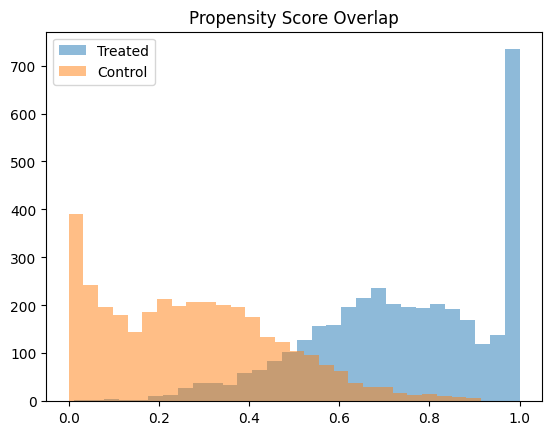

In [157]:
import matplotlib.pyplot as plt

# Access propensity predictions, use first cv fold model
ps = dr.models_propensity[0][0].predict_proba(X)[:, 1]

plt.hist(ps[T==1], bins=30, alpha=0.5, label="Treated")
plt.hist(ps[T==0], bins=30, alpha=0.5, label="Control")
plt.legend()
plt.title("Propensity Score Overlap")
plt.show()

In [138]:
print("Min PS:", ps.min())
print("Max PS:", ps.max())
print("Percentiles:", np.percentile(ps, [1,5,50,95,99]))

Min PS: 2.3725186e-05
Max PS: 0.99993956
Percentiles: [0.00363061 0.02929905 0.51807031 0.99364309 0.99826   ]


#### Inspect Weight Stability

In [139]:
p_treat = np.mean(T)

weights = np.where(
    T == 1,
    p_treat / ps,
    (1 - p_treat) / (1 - ps)
)

print("Weight summary:")
print(pd.Series(weights).describe())

# Effective Sample Size
ess = (np.sum(weights)**2) / np.sum(weights**2)
print("Effective Sample Size:", ess)

Weight summary:
count    7244.000000
mean        0.777746
std         0.720502
min         0.484827
25%         0.550764
50%         0.671374
75%         0.831556
max        43.057693
dtype: float64
Effective Sample Size: 3898.6177183414143


#### Verify Covariate Balance 

In [140]:
def weighted_mean(x, w):
    return np.sum(x*w) / np.sum(w)

def weighted_var(x, w):
    mu = weighted_mean(x, w)
    return np.sum(w*(x-mu)**2) / np.sum(w)

def weighted_smd(x, T, w):
    mean_t = weighted_mean(x[T==1], w[T==1])
    mean_c = weighted_mean(x[T==0], w[T==0])
    var_t = weighted_var(x[T==1], w[T==1])
    var_c = weighted_var(x[T==0], w[T==0])
    return (mean_t - mean_c) / np.sqrt((var_t + var_c)/2)

smds = pd.Series({
    col: weighted_smd(X[col].values, T.values, weights)
    for col in X.columns
})

print(smds.sort_values(key=abs, ascending=False))

cat__Income_9         0.292687
cat__Income_10        0.255235
cat__Homeintserv_2   -0.248382
cat__Homeintserv_0   -0.190019
cat__Homeintserv_5    0.162912
                        ...   
cat__Pray_Freq_4      0.000161
cat__Marital_1        0.000113
cat__Instagram_1      0.000054
cat__Hh_Adults_4     -0.000040
cat__Race_4          -0.000033
Length: 187, dtype: float64


#### Outcome Model Diagnostics

In [141]:
# For binary outcome
outcome_models = dr.models_regression[0]
outcome_models

preds = np.mean([
    m.predict_proba(X)
    for m in outcome_models
], axis=0)

print("Outcome model AUC:", roc_auc_score(y, preds))


/Users/jenniferle/anaconda3/envs/opinion_analysis/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


ValueError: X has 187 features, but RandomForestClassifier is expecting 188 features as input.

#### Run Placebo Test

In [142]:
# delete columns that were used to make the treatment and outcome columns
drop = ['Treatment','Outcome','Year','Econ_Rating','Econ_Outlook','Econ_Sentiment']
X = df_causal_factorized.drop(columns=drop)
T_fake = np.random.permutation(T)
y = df_causal_factorized['Outcome']

dr_fake = DRLearner(
    model_propensity=XGBClassifier(random_state=42), # predict treatment (propensity score)
    model_regression=RandomForestClassifier(max_depth=6,random_state=42), # predict outcomes
    model_final=Lasso(alpha=0.0001,random_state=42), # eliminate features, avoids "Co-variance matrix is underdetermined" warning
    discrete_outcome=True, # predicting binary outcome
    cv=StratifiedKFold(n_splits=5,random_state=98,shuffle=True)
)

X = build_column_transformer(X,scale=True).fit_transform(X)

# Estimate the counterfactual model from data
dr_fake.fit(y.to_numpy().ravel(), T_fake, X=X, inference='bootstrap')

print("Fake ATE:", dr_fake.ate(X))

/Users/jenniferle/anaconda3/envs/opinion_analysis/lib/python3.10/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/jenniferle/anaconda3/envs/opinion_analysis/lib/python3.10/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/jenniferle/anaconda3/envs/opinion_analysis/lib/python3.10/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/jenniferle/anaconda3/envs/opinion_analysis/lib/python3.10/site-packages/sklearn/b

Fake ATE: [-0.01304338]


#### Check CATE Stability

In [156]:
cate = dr.effect(X)
cate
modified_cate = []
for c in cate:
    modified_cate.append(c[0].item())
modified_cate

print("CATE summary:")
print(pd.Series(modified_cate).describe())

CATE summary:
count    7244.000000
mean        0.209942
std         0.436007
min        -1.871590
25%        -0.035578
50%         0.167854
75%         0.394353
max         5.715528
dtype: float64


#### Confirm ATE robustness

In [ ]:
# check bootstraped interval
dr.ate_inference(X)

In [ ]:
# change nuisance model

# delete columns that were used to make the treatment and outcome columns
drop = ['Treatment','Outcome','Year','Econ_Rating','Econ_Outlook','Econ_Sentiment']
X = df_causal_factorized.drop(columns=drop)
T = df_causal_factorized['Treatment']
y = df_causal_factorized['Outcome']

model_propensity = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    random_state=42
)

model_regression = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    random_state=42
)

dr = DRLearner(
    model_propensity=model_propensity, # predict treatment (propensity score)
    model_regression=model_regression, # predict outcomes
    model_final=Lasso(alpha=0.0001,random_state=42), # eliminate features, avoids "Co-variance matrix is underdetermined" warning
    discrete_outcome=True, # predicting binary outcome
    cv=StratifiedKFold(n_splits=5,random_state=98,shuffle=True)
)

X = build_column_transformer(X,scale=True).fit_transform(X)

# Estimate the counterfactual model from data
dr.fit(y.to_numpy().ravel(), T, X=X, inference='bootstrap')
ate = dr.ate(X)
cate = dr.effect(X)

ate

/Users/jenniferle/anaconda3/envs/opinion_analysis/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/jenniferle/anaconda3/envs/opinion_analysis/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/jenniferle/anaconda3/envs/opinion_analysis/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/jenniferle/anaconda3/envs/opinion_analysis/lib/python3.10/site-packages/sklear

## Other

In [21]:
# delete columns that were used to make the treatment and outcome columns
drop = ['Treatment','Outcome','Year','Econ_Rating']
X,y = df_causal_factorized.drop(columns=drop), df_causal_factorized['Treatment']

# 5-fold cross validation
cv5 = StratifiedKFold(n_splits=5,random_state=42,shuffle=True)

#  3-fold cv for models that take longer to train e.g random forest
cv3 = StratifiedKFold(n_splits=3,random_state=42,shuffle=True) 

# returns the average roc auc score of all cross validation folds
def cv_score(estimator,cv):
    avg_score = round(cross_val_score(
        X=X,
        y=y,
        estimator=estimator,
        scoring='roc_auc',
        cv=cv,
        n_jobs=-1
    ).mean(),6)
    return avg_score

### Logistic Regression

In [144]:
pipe = Pipeline([
    ("ct", build_column_transformer(X,scale=True)),
    ("clf", LogisticRegression(solver='saga',penalty='l1',C=0.1,random_state=42))
])
cv_score(pipe,cv5).item()

0.778737

In [146]:
def objective(trial):
    params = {
        "penalty": trial.suggest_categorical("penalty",["l1","l2"]),
        "C": trial.suggest_float("C", 0.00001, 1, log=True),
        "max_iter": trial.suggest_int("max_iter", 100,500),
        "solver": "saga",
        "random_state": 42
    }

    pipe = Pipeline([
        ("ct", build_column_transformer(X,scale=True)),
        ("clf", LogisticRegression(**params))
    ])

    return cv_score(pipe,cv5)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

print(study.best_params)
print(study.best_value)

[I 2026-02-13 19:04:25,903] A new study created in memory with name: no-name-62157317-04d2-4ee3-a613-26184c00a187
[I 2026-02-13 19:04:27,960] Trial 0 finished with value: 0.778048 and parameters: {'penalty': 'l2', 'C': 0.95984726150151, 'max_iter': 199}. Best is trial 0 with value: 0.778048.
[I 2026-02-13 19:04:28,607] Trial 1 finished with value: 0.774691 and parameters: {'penalty': 'l2', 'C': 0.18809763607762164, 'max_iter': 426}. Best is trial 0 with value: 0.778048.
[I 2026-02-13 19:04:28,842] Trial 2 finished with value: 0.5 and parameters: {'penalty': 'l1', 'C': 0.0017679381318865572, 'max_iter': 160}. Best is trial 0 with value: 0.778048.
[I 2026-02-13 19:04:29,194] Trial 3 finished with value: 0.624588 and parameters: {'penalty': 'l1', 'C': 0.010513597071390915, 'max_iter': 372}. Best is trial 0 with value: 0.778048.
[I 2026-02-13 19:04:29,529] Trial 4 finished with value: 0.668188 and parameters: {'penalty': 'l2', 'C': 0.0019513314955456544, 'max_iter': 358}. Best is trial 0 w

{'penalty': 'l1', 'C': 0.25601841488075777, 'max_iter': 128}
0.782837


### XGBoost

In [23]:
pipe = Pipeline([
    ("ct", build_column_transformer(X,scale=False)),
    ("clf", XGBClassifier(random_state=42,n_jobs=-1))
])
cv_score(pipe,cv5).item()

0.764866

In [148]:
def objective(trial):
    params = {
        "objective": "binary:logistic",
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 100),
        "gamma": trial.suggest_float("gamma", 1e-8, 10.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.4, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.3, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 100.0, log=True),
        "random_state": 42,
        "n_jobs": -1
    }

    pipe = Pipeline([
        ("ct", build_column_transformer(X,scale=False)),
        ("clf", XGBClassifier(**params))
    ])
    return cv_score(pipe,cv5)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=200)

print(study.best_params)
print(study.best_value)

[I 2026-02-13 19:06:27,859] A new study created in memory with name: no-name-48233873-4513-4661-b2e5-5ae62de4012e
[I 2026-02-13 19:06:28,741] Trial 0 finished with value: 0.628977 and parameters: {'max_depth': 10, 'min_child_weight': 68, 'gamma': 5.4159235240373516, 'subsample': 0.5436627128473132, 'colsample_bytree': 0.48031848963905466, 'learning_rate': 0.0010206238241907584, 'n_estimators': 279, 'reg_alpha': 0.0011978826310136508, 'reg_lambda': 76.21965047950127}. Best is trial 0 with value: 0.628977.
[I 2026-02-13 19:06:29,667] Trial 1 finished with value: 0.635438 and parameters: {'max_depth': 10, 'min_child_weight': 93, 'gamma': 1.805013960538624e-06, 'subsample': 0.5944769693631564, 'colsample_bytree': 0.8334161117523198, 'learning_rate': 0.0038469418753142486, 'n_estimators': 251, 'reg_alpha': 0.030036534420991294, 'reg_lambda': 0.009531427691522898}. Best is trial 1 with value: 0.635438.
[I 2026-02-13 19:06:30,718] Trial 2 finished with value: 0.63607 and parameters: {'max_dep

{'max_depth': 6, 'min_child_weight': 5, 'gamma': 4.7662332091999966e-07, 'subsample': 0.8506207466250167, 'colsample_bytree': 0.9207325013671921, 'learning_rate': 0.02192065825226832, 'n_estimators': 421, 'reg_alpha': 0.14650289799874774, 'reg_lambda': 2.3667259504040503}
0.785347


### Calculate Propensity Score

In [24]:
best_params = {
    "objective": "binary:logistic",
    'max_depth': 10, 
    'min_child_weight': 6, 
    'gamma': 2.128139966856821, 
    'subsample': 0.767437929541573, 
    'colsample_bytree': 0.7202530987860138, 
    'learning_rate': 0.04229494177482168, 
    'n_estimators': 455, 
    'reg_alpha': 0.005338992308523779, 
    'reg_lambda': 24.00557869406512,
    "random_state": 42,
    "n_jobs": -1
}
pipe = Pipeline([
        ("ct", build_column_transformer(X,scale=False)),
        ("clf", XGBClassifier(**best_params))
    ])

pipe.fit(X,y)

propensity_score = pipe.predict_proba(X)[:, 1]
df_causal['propensity_score'] = propensity_score
df_causal_factorized['propensity_score'] = propensity_score